Here we consider the clustering a collection of vectors into groups or clusters of vectors that are close to each other, as measured by the distance between pairs of them, using famous clustering method, called the *k-means* algorithm, and give some typical applications.
The k-means algorithm is widely used in practical applications, and rely only on the idea of the distance from the vectors to their associated representatives.

Clustering is very widely used in many application areas, typically (but not always) when the vectors represent features of objects. Suppose we have $N$ $n$-vectors, $x_1,...,x_N$. The goal of clustering is to group or partition the vectors (if possible) into $k$ groups or clusters, with the vectors in each group close to each other. Normally we have $k$ much smaller than $N$.

K-means clustering is an unsupervised method of classifying multivariate data into a relatively small number of groups, or categories, based on minimizing distance to the group center.
K-means clustering is an important analysis method in machine learning, and there are sophisticated variants of k-means clustering. Here we will implement a simple version of k-means, with the goal of seeing how concepts about vectors (in particular: vectors, vector norms, and broadcasting) are used in the k-means algorithm.


In [87]:
import numpy as np
import numpy.linalg as npl
import matplotlib.pyplot as plt

# Clustering & A Clustering Objective

1. "The goal of clustering is to group of partition vectors into k groups or clusters, with the vectors in each group close to each other"
2. Objective: A single value used to judge "choice of clustering": choose k

We can now give a single number that we use to judge a
choice of clustering, along with a choice of the group representatives. We define
$$J_{clust} =(||x_1 - z_{c1}||^2_2 +···+||x_N - z_{cN}||^2_2)/N $$
which is the mean square distance from the vectors to their associated representatives. Note that $J_{clust}$ depends on the cluster assignments (i.e., c), as well as the choice of the group representatives $z_1, . . . , z_k$. The smaller $J_{clust}$ is, the better the clustering. An extreme case is $J_{clust}$ = 0, which means that the distance be- tween every original vector and its assigned representative is zero. This happens only when the original collection of vectors only takes k different values, and each vector is assigned to the representative it is equal to. (This extreme case would probably not occur in practice.)

So if we fix the group assignments, we minimize $J_{clust}$ by choosing each group representative to be the average or centroid of the vectors assigned to its group. (This is sometimes called the group centroid or cluster centroid.)
The algorithm is quite sensitive to the choice of the initial centers, so try multiple starting values.

1. Initialize a group of representatives either by: 1) randomly selecting from set of vectors, or 2) randomly group vectors and create mean vectors to be used as representatives.
2. Partition vectors in k amount of groups. Assign a group for every vector associated with the nearest representative.
If there are any ties for vector assignments, choose the group with the smallest j value of the ties.
If there is an empty group, remove from list of k groups.
If there are two iterations without changes in vector assignments, stop algorithm.
3. Update representatives. For every group from 1-k set the corresponding representative to be the mean of the vectors in that group.
If $J_{clust}$ gets small, stop algorithm.

In [88]:
#given a tuple of vectors, and representatives for groups of vectors,
#what is the average distance each vector has from a representative

x = np.array([[0,1],[1,0],[-1,1]])
reps = np.array([[1,1],[0,0]])

jclust = lambda x, reps, assignment: np.average([npl.norm(x[i] - reps[assignment[i]])**2 for i in range(len(x))])
jclust(x,reps,[0,1,0]),jclust(x,reps,[0,0,1]) #assignments are 0 indexed

#How can we select the center-most (most minimal distance between vectors)
#representative?

(np.float64(2.0), np.float64(1.3333333333333333))

# k-Means Algorithm

Iterating between choosing group representatives and choosing group assignments:

1. Initialize $k$ centroids as random points in the data space. Each centroid is a “class,” or category, and the steps below will assign each data observation to each class. (A “centroid” is a center generalized to any number of dimensions.)
2. Compute the Euclidean distance between each data observation and each centroid.
3. Assign each data observation to the group with the closest centroid.
4. Update each centroid as the average of all data observations assigned to that centroid.
5. Repeat steps 2-4 until a convergence criteria is satisfied, or for $N$ iterations.

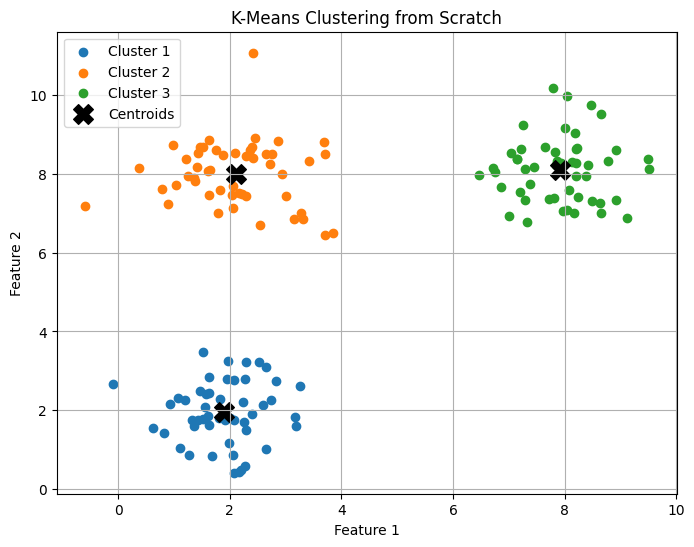

In [102]:
import numpy as np
import matplotlib.pyplot as plt

def euclidean_distance(point1, point2):
    """Calculates the Euclidean distance between two points."""
    return np.linalg.norm(point1 - point2)

def assign_to_clusters(data, centroids):
    """Assigns each data point to the closest centroid."""
    assignments = np.zeros(len(data), dtype=int)
    for i, point in enumerate(data):
        distances = [euclidean_distance(point, centroid) for centroid in centroids]
        assignments[i] = np.argmin(distances)
    return assignments

def update_centroids(data, assignments, k):
    """Recalculates the centroids based on the mean of assigned points."""
    new_centroids = np.zeros((k, data.shape[1]))
    for i in range(k):
        points_in_cluster = data[assignments == i]
        if len(points_in_cluster) > 0:
            new_centroids[i] = np.mean(points_in_cluster, axis=0)
    return new_centroids

def kmeans(data, k, max_iterations=100, visualize=False):
    """
    Performs K-Means clustering.

    Args:
        data (np.array): The input data points.
        k (int): The number of clusters.
        max_iterations (int): The maximum number of iterations.

    Returns:
        tuple: A tuple containing the final centroids and cluster assignments.
    """
    # Initialize centroids randomly
    # Select k random data points as initial centroids
    random_indices = np.random.choice(len(data), k, replace=False)
    centroids = data[random_indices]

    for i in range(max_iterations):
        assignments = assign_to_clusters(data, centroids)
        new_centroids = update_centroids(data, assignments, k)

        # Check for convergence
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids

        if visualize:
            print('Iteration %d'%i)
            plt.scatter(data[:, 0], data[:, 1], c=assignments)
            plt.scatter(centroids[:,0],centroids[:,1], c='r')
            plt.pause(0.1)


    return centroids, assignments

# Generate some sample data
np.random.seed(42) # for reproducibility
data = np.concatenate([
    np.random.normal(loc=[2, 2], scale=0.8, size=(50, 2)),
    np.random.normal(loc=[8, 8], scale=0.8, size=(50, 2)),
    np.random.normal(loc=[2, 8], scale=0.8, size=(50, 2))
])

# Set the number of clusters
k = 3

# Run K-Means
centroids, assignments = kmeans(data, k)

# Visualize the results
plt.figure(figsize=(8, 6))
for i in range(k):
    cluster_points = data[assignments == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i+1}')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='black', label='Centroids')
plt.title('K-Means Clustering from Scratch')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [103]:
X = np.concatenate(
    [[.3*np.random.randn(2) for i in range(100)],
     [np.array([1,1]) + .3*np.random.randn(2) for i in range(100)],
     [np.array([1,-1]) + .3*np.random.randn(2) for i in range(100)]]
)

((-1.5, 2.5), (-2.0, 2.0))

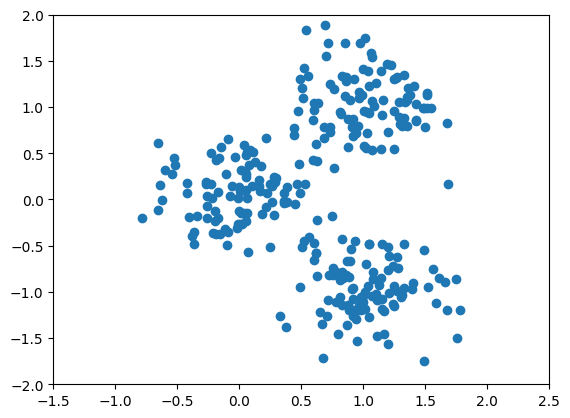

In [104]:
plt.scatter([x[0] for x in X],[x[1] for x in X])
plt.xlim([-1.5,2.5]),plt.ylim([-2,2])

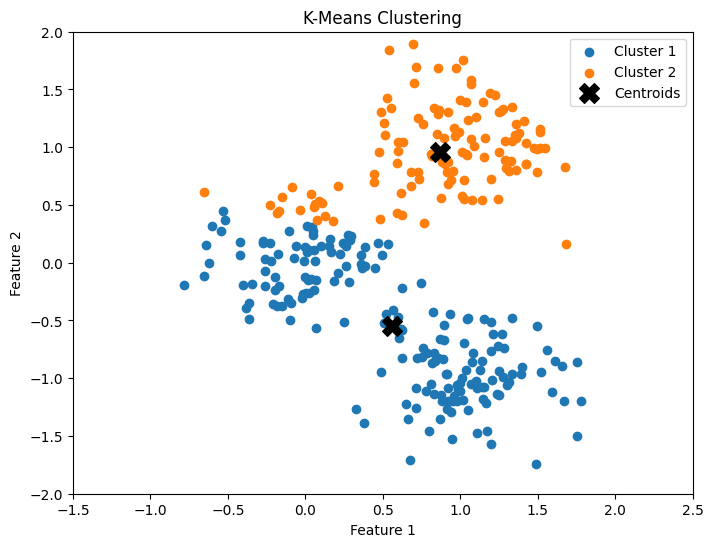

In [105]:
k=2

centroids, assignments = kmeans(X, k)
# Visualize the results
plt.figure(figsize=(8, 6))
for i in range(k):
    cluster_points = X[assignments == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i+1}')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='black', label='Centroids')
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
#plt.grid(True)
plt.xlim([-1.5,2.5]),plt.ylim([-2,2])
plt.show()

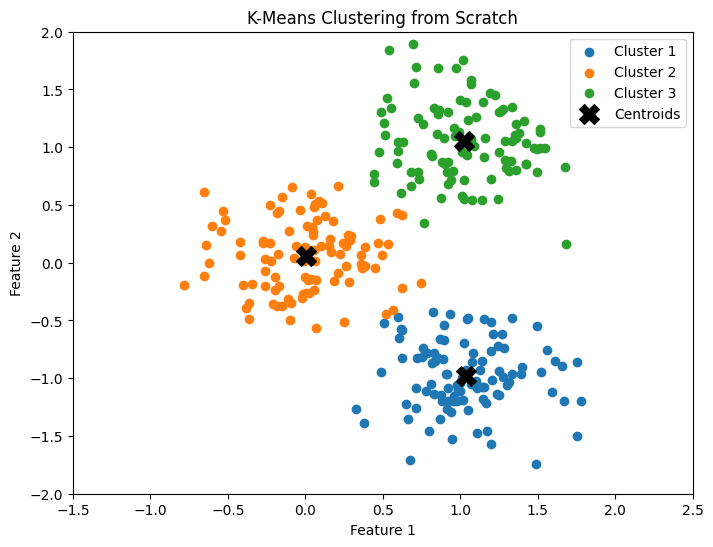

In [106]:
k=3

centroids, assignments = kmeans(X, k)
# Visualize the results
plt.figure(figsize=(8, 6))
for i in range(k):
    cluster_points = X[assignments == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i+1}')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='black', label='Centroids')
plt.title('K-Means Clustering from Scratch')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
#plt.grid(True)
plt.xlim([-1.5,2.5]),plt.ylim([-2,2])
plt.show()

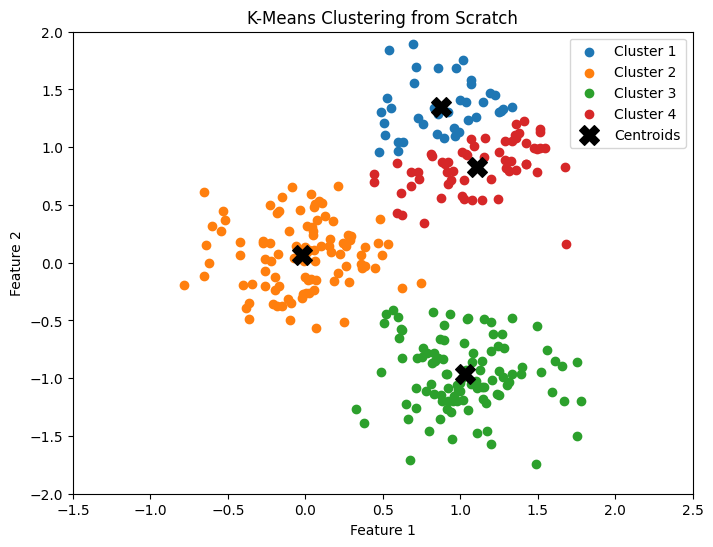

In [116]:
k=4

centroids, assignments = kmeans(X, k)
# Visualize the results
plt.figure(figsize=(8, 6))
for i in range(k):
    cluster_points = X[assignments == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i+1}')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='black', label='Centroids')
plt.title('K-Means Clustering from Scratch')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
#plt.grid(True)
plt.xlim([-1.5,2.5]),plt.ylim([-2,2])
plt.show()

#k-Means Clustering
Note that sklearn has a k-means clustering function.

Run the following several times. Do you observe a poor clustering result?

Iteration 0


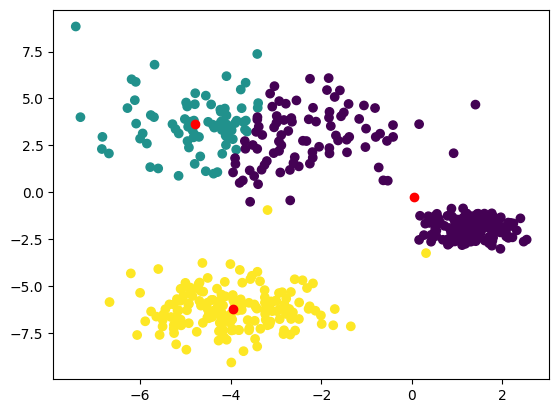

Iteration 1


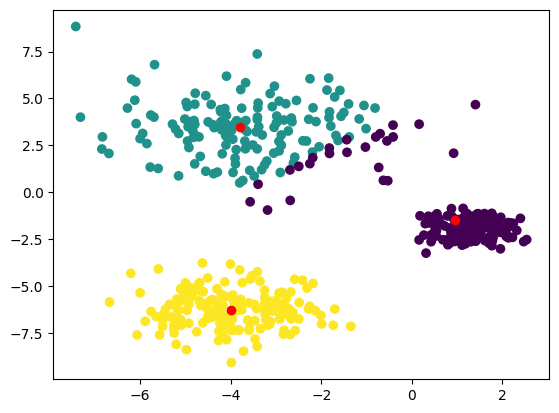

Iteration 2


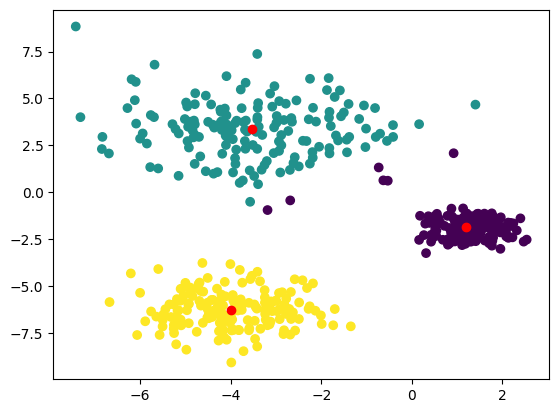

Iteration 3


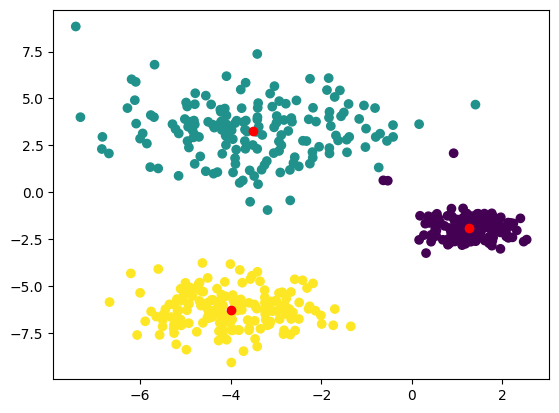

In [118]:
import sklearn.datasets as datasets

n = 500
X,L = datasets.make_blobs(n_samples=n, cluster_std=[1,1.5,0.5], random_state=60)
centroids, assignments = kmeans(X, 3, visualize=True)

##Limits of k-means
k-means has trouble with datasets where clusters are not generally spherical in shape, especially when different clusters have vastly different aspect ratios.

Iteration 1


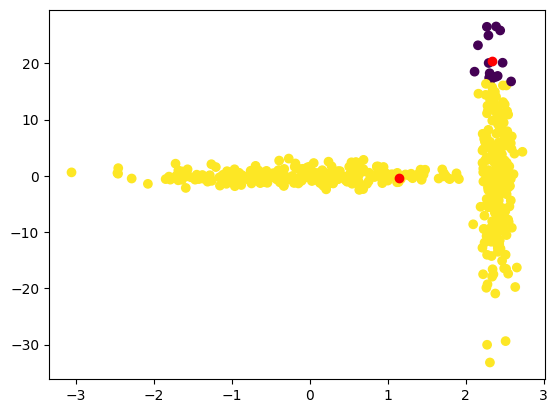

Iteration 2


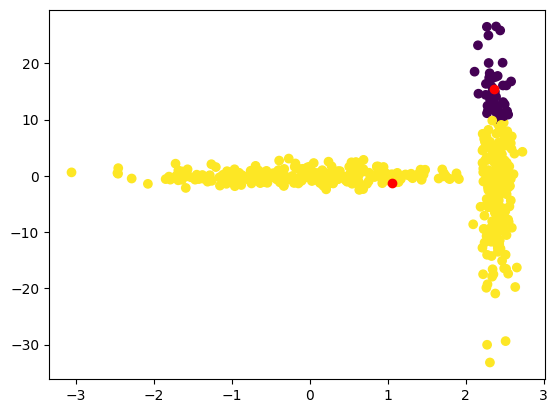

Iteration 3


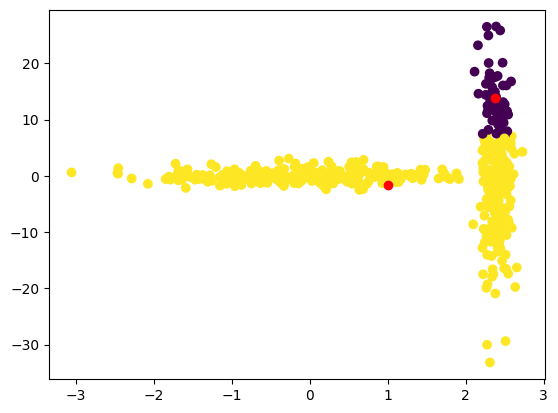

Iteration 4


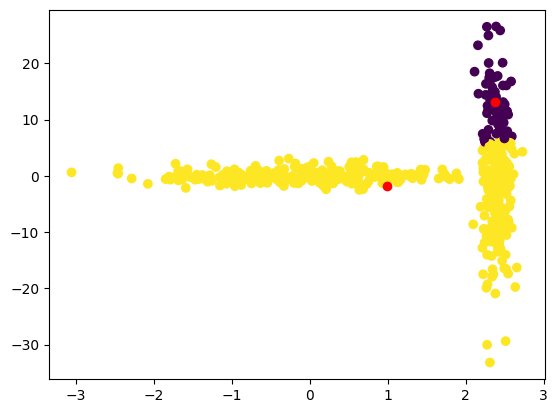

Iteration 5


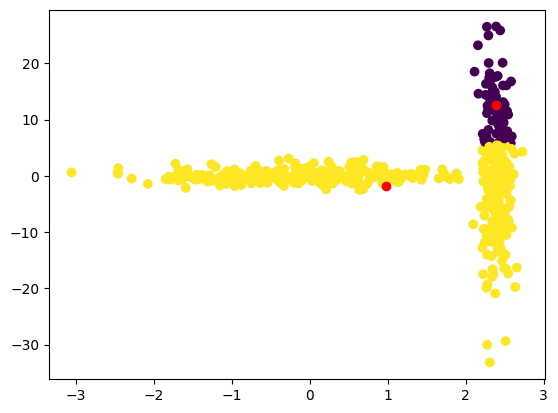

Iteration 6


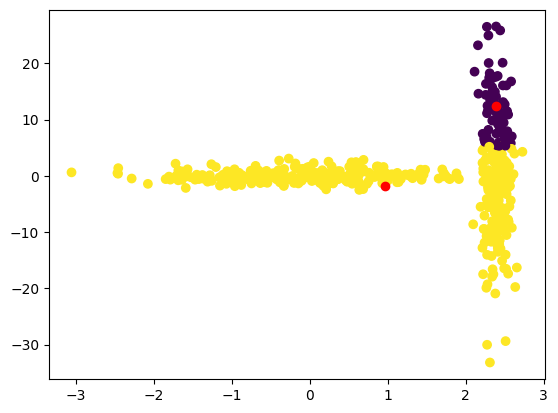

Iteration 7


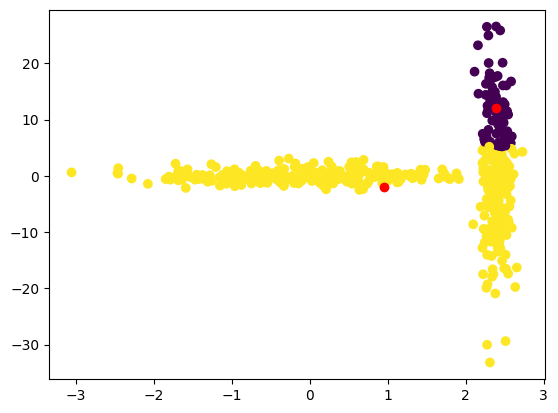

Iteration 8


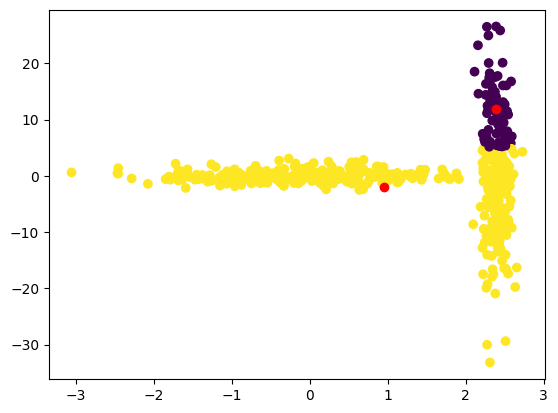

Iteration 9


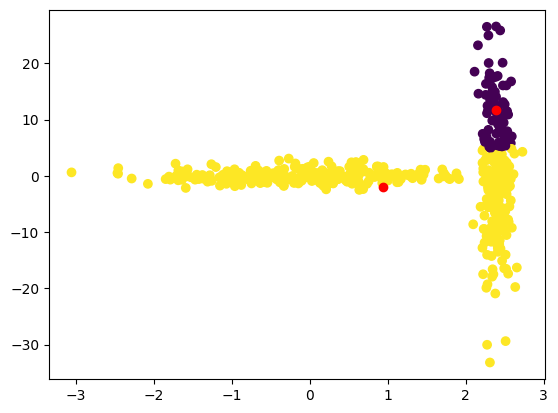

Iteration 10


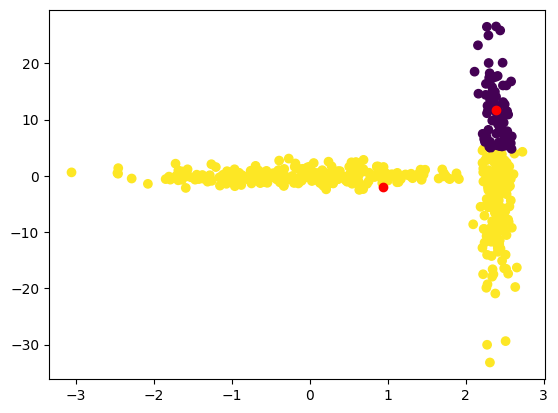

Iteration 11


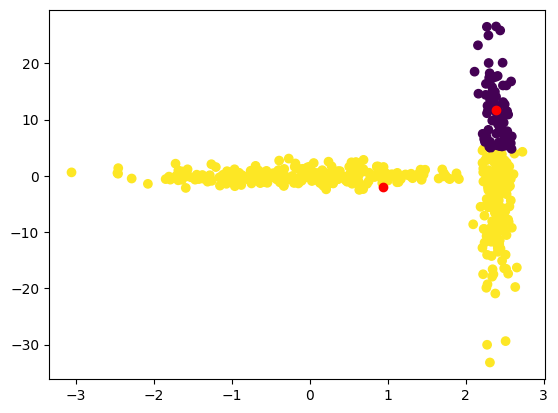

In [12]:
n = 500
separation = 0.8
X1 = np.random.randn(int(n/2),2)
L1 = np.zeros((n,))
X2 = np.random.randn(int(n/2),2)@np.array([[0.1,0],[0,10]]) + separation*np.array([3,0])
L2 = np.ones((n,))

X = np.vstack((X1,X2))
L = np.hstack((L1,L2))

centroids, assignments = kmeans(X,2,visualize=True)

Another interesting example is the famous two-moons.

Iteration 1


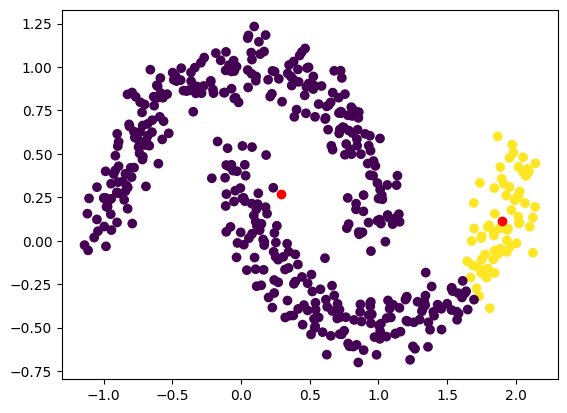

Iteration 2


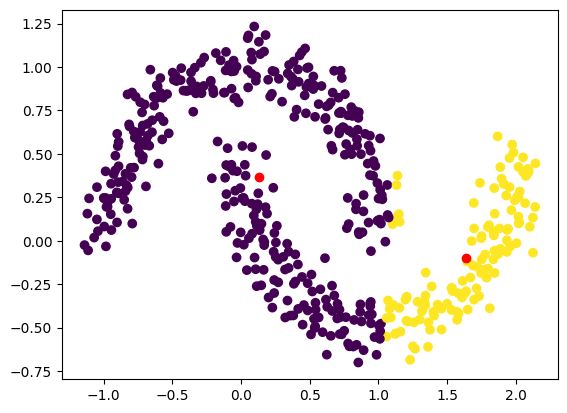

Iteration 3


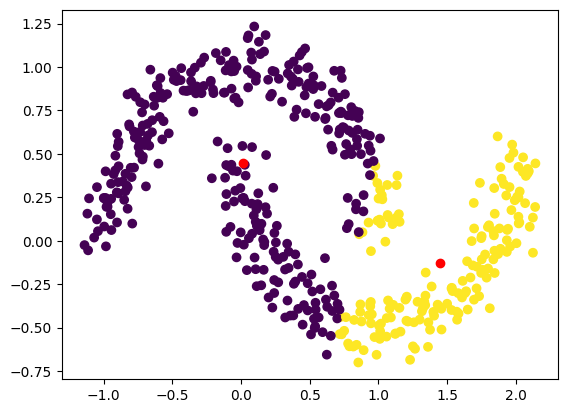

Iteration 4


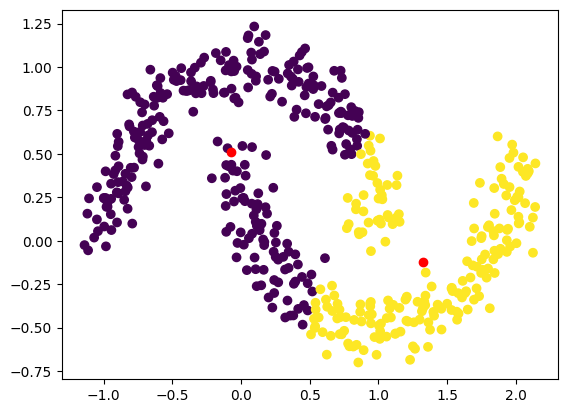

Iteration 5


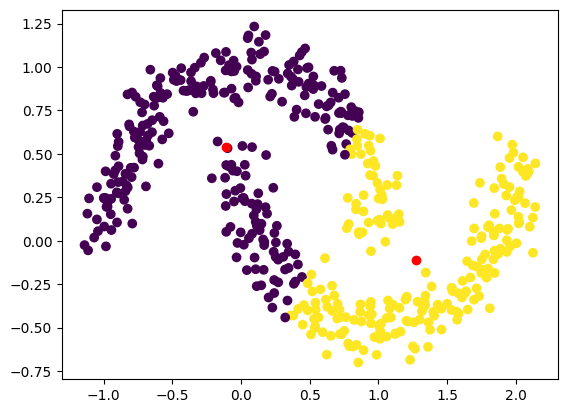

Iteration 6


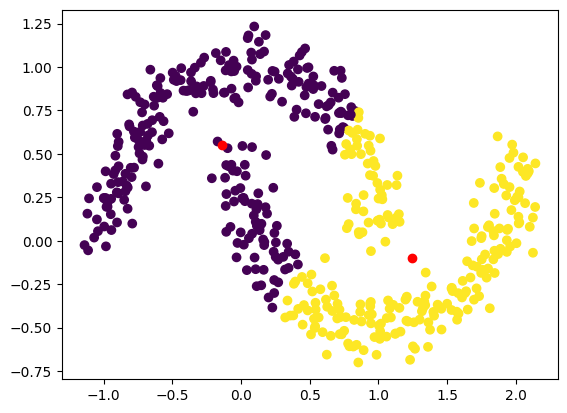

Iteration 7


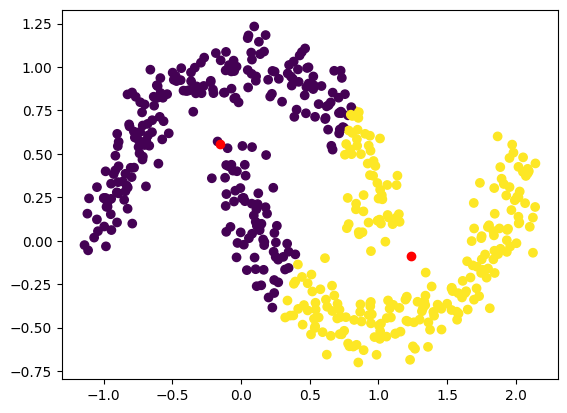

Iteration 8


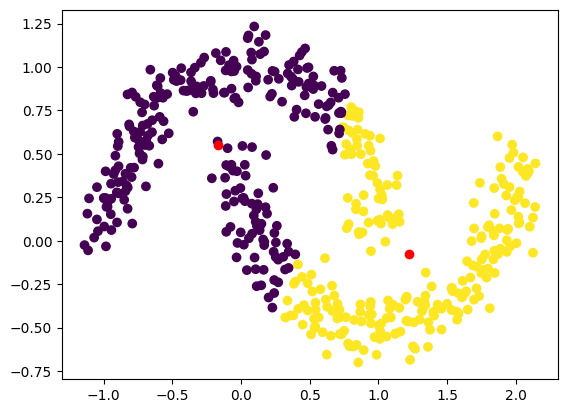

Iteration 9


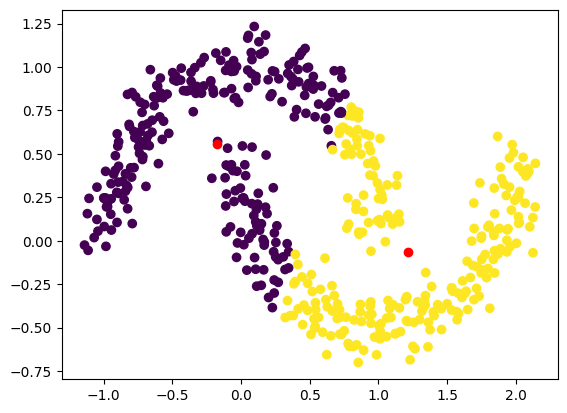

Iteration 10


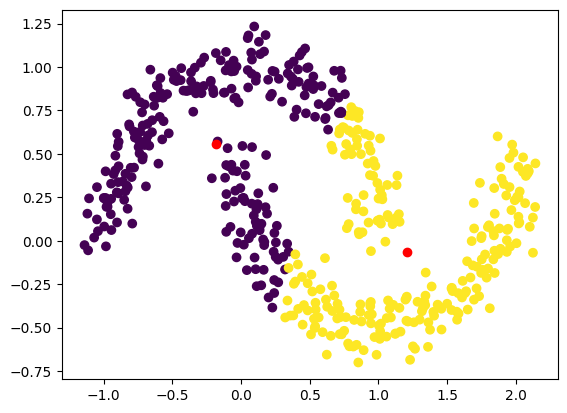

Iteration 11


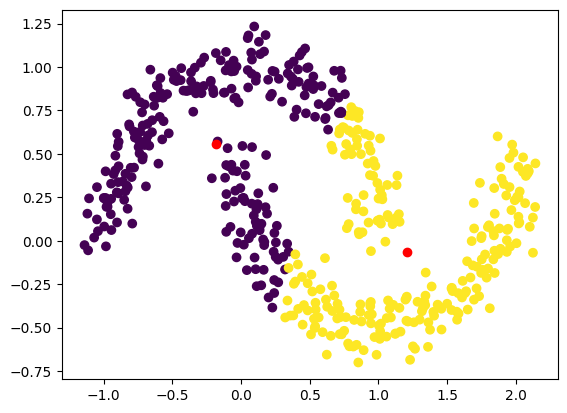

In [13]:
import sklearn.datasets as datasets

n=500
X,L = datasets.make_moons(n_samples=n,noise=0.1)

centroids, assignments = kmeans(X,2,visualize=True)

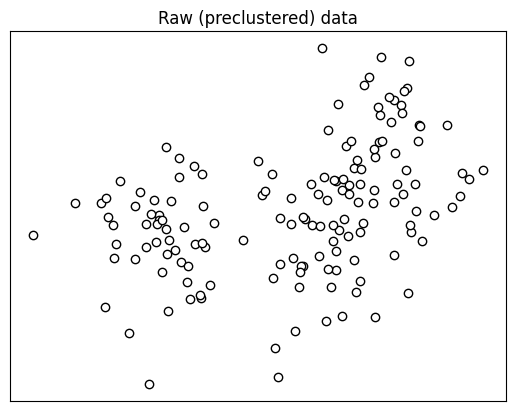

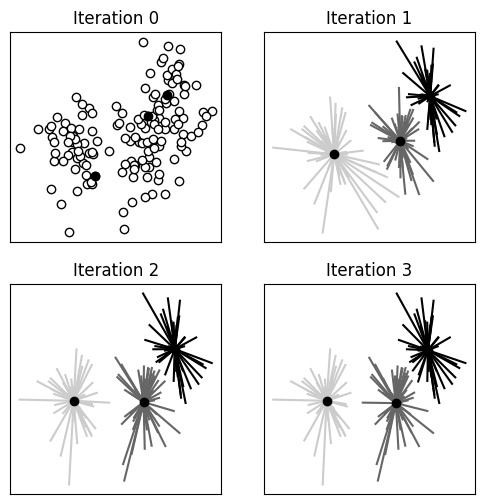

In [133]:
## Create data
nPerClust = 50

# blur around centroid (std units)
blur = 1

# XY centroid locations
A = [  1, 1 ]
B = [ -3, 1 ]
C = [  3, 3 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur , C[1]+np.random.randn(nPerClust)*blur ]

# concatanate into a matrix
data = np.transpose( np.concatenate((a,b,c),axis=1) )


# plot data
plt.plot(data[:,0],data[:,1],'ko',markerfacecolor='w')
plt.title('Raw (preclustered) data')
plt.xticks([])
plt.yticks([])

plt.show()

## initialize random cluster centroids
k = 3 # extract three clusters

# random cluster centers (randomly sampled data points)
ridx = np.random.choice(range(len(data)),k,replace=False)
centroids = data[ridx,:]


# setup the figure
fig,axs = plt.subplots(2,2,figsize=(6,6))
axs = axs.flatten()
lineColors = [ [0,0,0],[.4,.4,.4],[.8,.8,.8] ]#'rbm'


# plot data with initial random cluster centroids
axs[0].plot(data[:,0],data[:,1],'ko',markerfacecolor='w')
axs[0].plot(centroids[:,0],centroids[:,1],'ko')
axs[0].set_title('Iteration 0')
axs[0].set_xticks([])
axs[0].set_yticks([])



# loop over iterations
for iteri in range(3):

  # step 1: compute distances
  dists = np.zeros((data.shape[0],k))
  for ci in range(k):
    dists[:,ci] = np.sum((data-centroids[ci,:])**2,axis=1)

  # step 2: assign to group based on minimum distance
  groupidx = np.argmin(dists,axis=1)

  # step 3: recompute centers
  for ki in range(k):
    centroids[ki,:] = [ np.mean(data[groupidx==ki,0]), np.mean(data[groupidx==ki,1]) ]


  # plot data points
  for i in range(len(data)):
    axs[iteri+1].plot([ data[i,0],centroids[groupidx[i],0] ],[ data[i,1],centroids[groupidx[i],1] ],color=lineColors[groupidx[i]])
  axs[iteri+1].plot(centroids[:,0],centroids[:,1],'ko')
  axs[iteri+1].set_title(f'Iteration {iteri+1}')
  axs[iteri+1].set_xticks([])
  axs[iteri+1].set_yticks([])


plt.savefig('Figure_04_03.png',dpi=300)
plt.show()

##Real data
We now consider using k-means to cluster MNIST digits. Let's install the [Graph Learning](https://github.com/jwcalder/GraphLearning) Python package.

In [125]:
pip install -q graphlearning

Load MNIST data into memory.

In [126]:
import graphlearning as gl

data, labels = gl.datasets.load('mnist')

Let's plot some MNIST images.

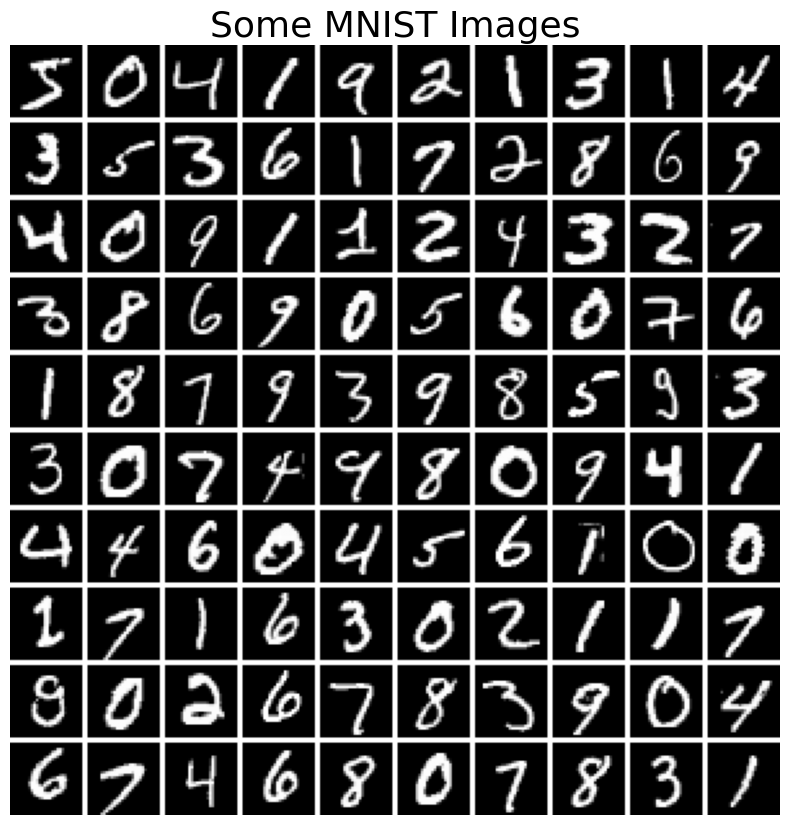

In [127]:
gl.utils.image_grid(data, n_rows=10, n_cols=10, title='Some MNIST Images', fontsize=26)

Clustering accuracy = 99.11%


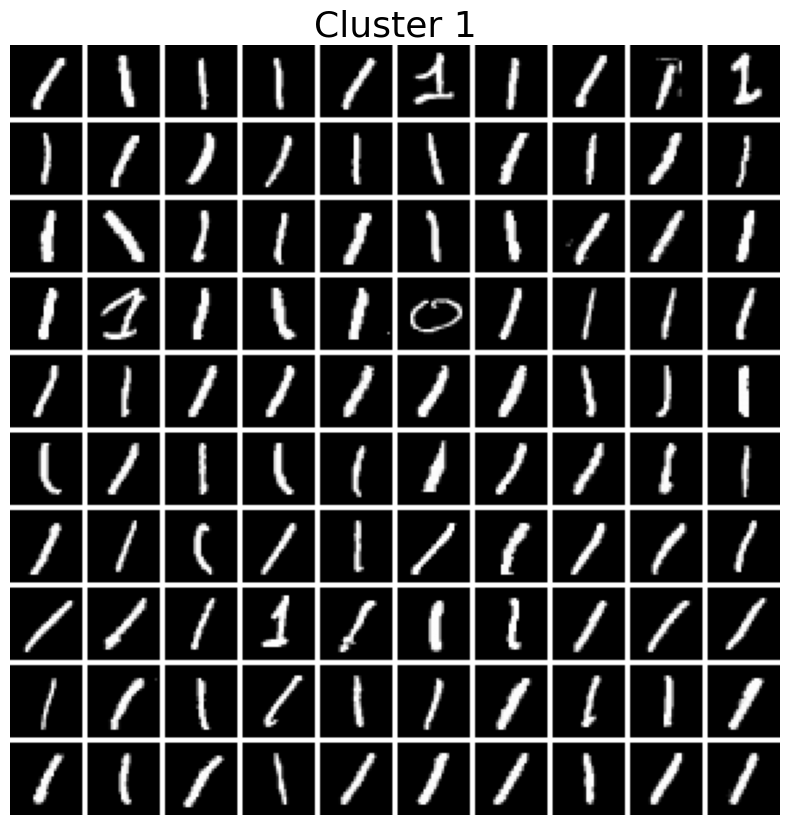

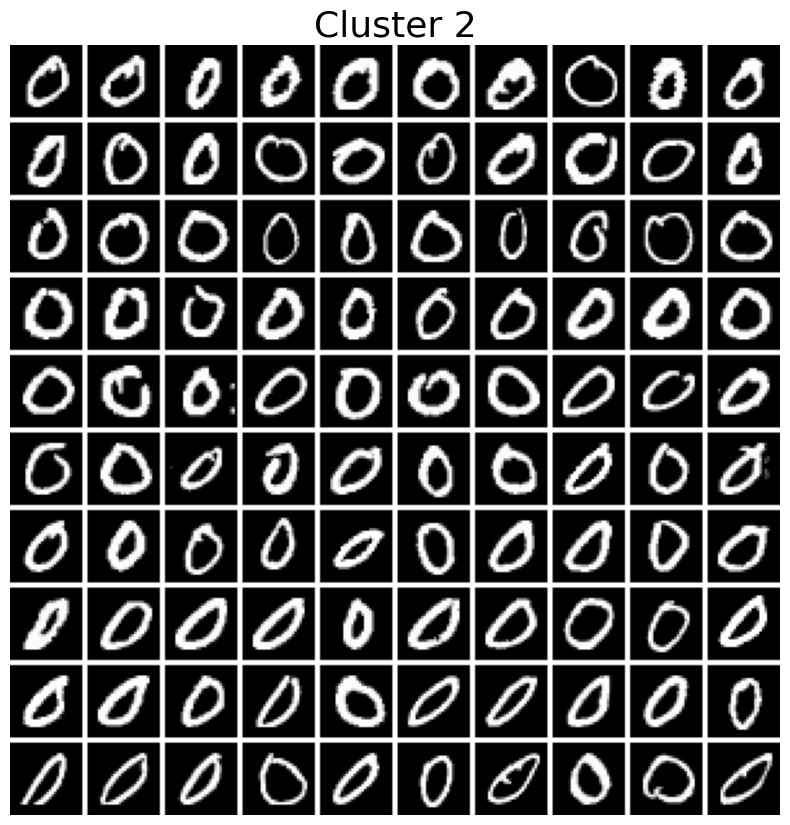

In [131]:
#Binary clustering problem witih 2 digits
class1 = 0
class2 = 1

#Subset data to three digits
I = labels == class1
J = labels == class2
X = data[I | J,:]
L = labels[I | J]

#Convert labels to 0/1
I = L == class1
L[I] = 0
L[~I] = 1

#kmeans clustering
centroids, cluster_labels = kmeans(X, 2)

#Check accuracy
acc1 = np.mean(cluster_labels == L)
acc2 = np.mean(cluster_labels != L)
print('Clustering accuracy = %.2f%%'%(100*max(acc1,acc2)))

#Show images from each cluster
gl.utils.image_grid(X[cluster_labels==0,:], n_rows=10, n_cols=10, title='Cluster 1', fontsize=26)
gl.utils.image_grid(X[cluster_labels==1,:], n_rows=10, n_cols=10, title='Cluster 2', fontsize=26)

## HW8-1

1. Play around with changing the two digits to cluster. Which two digits are most difficult to cluster?
2. Try k-means clustering with more than 2 classes. Try with 3, 4, or with the whole MNIST dataset. Describe your observations. Show image grids of each cluster.
3. Try applying $k$-means to another one of the real-world data sets in sklearn dataset.

## HW8-2

One way to determine an optimal $k$ is to repeat the clustering multiple times (each time using randomly initialized cluster centroids) and assess whether the final clustering is the same or different. Without generating new data, re-run the k-means code several times using $k=3$ to see whether the resulting clusters are similar (this is a qualitative assessment based on visual inspection). Do the final cluster assignments generally seem similar even though the centroids are randomly selected? Repeat the multiple clusterings using $k=2$ and $k=4$. What do you think of these results?